<a href="https://colab.research.google.com/github/kay-16/CSC173-DeepCV-Reambonanza/blob/main/efficientnet_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Train Model

| Step | Action | Description |
|------|-----------|-------|
| 1 | Input Stream | Capture real-time video frames from device webcam |
| 2 | PreProcessing | Resize frame and normalises pixel values |
| 3 | Stage 1: Detection (YOLOv8nY) | YOLOv8n (nano) determines and produces (output) the precise bounding box coordinates of the wire cluster |
| 4 | Cropping | Original frame is cropped to include only the wire clusters bounding box |
| 5 | Stage 2: Classification (EfficientNet-B0) | EfficientNet-B0 model processes the cropped image and classifies it (4 output neurons) |
| 6 | Decision Engine | Uses Softmax/Argmax to select one of the 4 classes |
| 7 | Final Output | Real-time display of the output class (e.g. Dangerous) and the FPS |

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.models as models
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from sklearn.metrics import precision_score, recall_score

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os

In [18]:
# Device setup
def set_device():
    """Sets the device to GPU (CUDA) if available, otherwise CPU."""
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    return device

In [19]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
DRIVE_ZIP_PATH = '/content/drive/MyDrive/classification_dataset/transformed_dataset.zip'

In [21]:
# Define the FAST local disk path where the data will be unzipped (for fast training)
LOCAL_DATASET_ROOT = '/content/local_classification_data'

In [22]:
# Create the local directory structure
!mkdir -p {LOCAL_DATASET_ROOT}

In [23]:
# Unzip data to local disk
print("Unzipping data from Drive to fast local disk...")
# the -d flag sets the destination directory
!unzip -q {DRIVE_ZIP_PATH} -d {LOCAL_DATASET_ROOT}

Unzipping data from Drive to fast local disk...
replace /content/local_classification_data/transformed_dataset/test/dangerous/0_image_10_proc.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [24]:
# Point to dataset paths using the new absolute local path
train_dataset_path = os.path.join(LOCAL_DATASET_ROOT, 'transformed_dataset', 'train')
test_dataset_path = os.path.join(LOCAL_DATASET_ROOT, 'transformed_dataset', 'test')
val_dataset_path = os.path.join(LOCAL_DATASET_ROOT, 'transformed_dataset', 'val')

In [25]:
# Make sure files exist
import os
print(os.path.exists(train_dataset_path))
print(os.path.exists(test_dataset_path))
print(os.path.exists(val_dataset_path))

True
True
True


In [27]:
mean=[0.485, 0.456, 0.406]
std=[0.229, 0.224, 0.225]

# Preprocessing pipeline for training data
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Transform and resize images
    transforms.RandomHorizontalFlip(), # Random flips
    transforms.RandomRotation(15),     # Rotate +/- 15 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Adjust brightness/contrast
    transforms.ToTensor(),             # Convert to tensor
    transforms.Normalize(torch.Tensor(mean), torch.Tensor(std)) # Normalise
])

# Preprocessing pipeline for validation and test data
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),     # Transform and resize images
    transforms.ToTensor(),             # Convert to tensor
    transforms.Normalize(torch.Tensor(mean), torch.Tensor(std)) # Normalise
])

In [42]:
# Create datasets
train_dataset = torchvision.datasets.ImageFolder(root=train_dataset_path, transform=train_transforms)
val_dataset = torchvision.datasets.ImageFolder(root=val_dataset_path, transform=val_test_transforms)
test_dataset = torchvision.datasets.ImageFolder(root=test_dataset_path, transform=val_test_transforms)

In [29]:
# Load datasets into dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [44]:
def eval_model(model, test_loader, criterion, device):
    model.eval() # Set model to evaluation mode
    model.to(device)

    running_loss = 0.0
    total = 0

    all_preds = []
    all_labels = []

    # Deactivate autograd for evaluation
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, predicted = torch.max(outputs, 1)

            running_loss += loss.item() * inputs.size(0)
            total += labels.size(0)

            # Store for precision & recall
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    # Use accuracy_score for correct overall accuracy calculation
    epoch_acc = (torch.sum(torch.tensor(all_preds) == torch.tensor(all_labels)).item() / total) * 100

    # Precision & recall (macro = average across classes)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0) * 100
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0) * 100

    # RETURN 6 VALUES (The essential change)
    return epoch_loss, epoch_acc, precision, recall, all_labels, all_preds


In [31]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, device):
    model.to(device) # Move model to device (GPU/CPU)

    # Initialize lists to track metrics
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    val_precisions = []
    val_recalls = []

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        model.train() # Set model to training mode

        running_loss = 0.0
        running_corrects = 0
        total = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Set gradient to zero
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels) # Using the Cross Entropy Loss between outputs(pred) and labels(true values)

            _, preds = torch.max(outputs, 1) # Get the index of the max log-probability

            # Perform backpropagation to calculate weight gradience and optimization
            loss.backward()
            optimizer.step()

            # Update running loss and correct predictions
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels)
            total += labels.size(0)

        epoch_loss = running_loss / total
        epoch_acc = 100.0 * running_corrects.item() / total

        # Store train metrics
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)

        # Validation
        val_loss, val_acc, val_precision, val_recall = eval_model(
           model, val_loader, criterion, device)

        val_losses.append(val_loss)
        val_accs.append(val_acc)
        val_precisions.append(val_precision)
        val_recalls.append(val_recall)

        print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

        scheduler.step()

    print('Finished Training')
    return model, train_losses, train_accs, val_losses, val_accs, val_precisions, val_recalls


In [32]:
efficientnet_b0_model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# 1. FREEZE THE BASE LAYERS (Feature Extractor)
# This prevents the pre-trained weights from changing during Phase 1 training.
for param in efficientnet_b0_model.features.parameters():
    param.requires_grad = False # Set to False to FREEZE the layers, set back to TRUE for fine-tune

# 2. MODIFY THE CLASSIFIER HEAD
# This replaces the final layer to match your 4 output classes.
num_ftrs = efficientnet_b0_model.classifier[1].in_features
num_of_classes = 4
efficientnet_b0_model.classifier[1] = nn.Linear(num_ftrs, num_of_classes)

# Set device and move model
device = set_device()
efficientnet_b0_model = efficientnet_b0_model.to(device)

# Define Loss, Optimizer, and Scheduler (Only the new classifier head parameters will train)
loss_func = nn.CrossEntropyLoss()

# Only parameters with requires_grad=True (the new classifier head) will be optimized
optimizer = optim.Adam(efficientnet_b0_model.parameters(), lr=0.0001, weight_decay=0.0001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 156MB/s]


Using device: cuda:0


In [34]:
# Start training
model, train_losses, train_accs, val_losses, val_accs, val_precisions, val_recalls = train_model(
    efficientnet_b0_model,
    train_loader,
    val_loader,
    loss_func,
    optimizer,
    scheduler,
    num_epochs=50,
    device=device
)


Epoch 1/50
Epoch 1/50 | Train Loss: 1.4013 | Train Acc: 23.78% | Val Loss: 1.3308 | Val Acc: 28.57%

Epoch 2/50
Epoch 2/50 | Train Loss: 1.3772 | Train Acc: 23.78% | Val Loss: 1.3080 | Val Acc: 35.71%

Epoch 3/50
Epoch 3/50 | Train Loss: 1.3765 | Train Acc: 27.97% | Val Loss: 1.2950 | Val Acc: 42.86%

Epoch 4/50
Epoch 4/50 | Train Loss: 1.3655 | Train Acc: 34.27% | Val Loss: 1.2804 | Val Acc: 46.43%

Epoch 5/50
Epoch 5/50 | Train Loss: 1.3507 | Train Acc: 34.27% | Val Loss: 1.2779 | Val Acc: 53.57%

Epoch 6/50
Epoch 6/50 | Train Loss: 1.3446 | Train Acc: 26.57% | Val Loss: 1.2694 | Val Acc: 53.57%

Epoch 7/50
Epoch 7/50 | Train Loss: 1.3369 | Train Acc: 33.57% | Val Loss: 1.2675 | Val Acc: 53.57%

Epoch 8/50
Epoch 8/50 | Train Loss: 1.3518 | Train Acc: 32.87% | Val Loss: 1.2600 | Val Acc: 57.14%

Epoch 9/50
Epoch 9/50 | Train Loss: 1.3298 | Train Acc: 36.36% | Val Loss: 1.2565 | Val Acc: 57.14%

Epoch 10/50
Epoch 10/50 | Train Loss: 1.3179 | Train Acc: 41.26% | Val Loss: 1.2529 | Val 

### Model Save to Gdrive

In [35]:
# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
# Create a folder where final weights are stored in Drive root
DRIVE_SAVE_DIR = '/content/drive/MyDrive/EfficientNet_Final_Weights'

# Create the directory if it doesn't exist
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)

In [37]:
# Define the full file path for the saved weights
SAVE_PATH = os.path.join(DRIVE_SAVE_DIR, 'efficientnet_b0_best.pth')

In [38]:
# Save the trained model's state dictionary
# The variable 'model' holds final trained efficientnet_b0_model
torch.save(model.state_dict(), SAVE_PATH)

print(f"\nSUCCESS: Trained model saved to Google Drive at: {SAVE_PATH}")


SUCCESS: Trained model saved to Google Drive at: /content/drive/MyDrive/EfficientNet_Final_Weights/efficientnet_b0_best.pth


# Fine tuning

In [39]:
# PHASE 2: FINE-TUNING THE ENTIRE MODEL

print("\n" + "="*50)
print("STARTING PHASE 2: FINE-TUNING")
print("="*50)

# Define the paths from the previous block
DRIVE_SAVE_DIR = '/content/drive/MyDrive/EfficientNet_Final_Weights'
LOAD_PATH = os.path.join(DRIVE_SAVE_DIR, 'efficientnet_b0_best.pth')
FINAL_SAVE_PATH = os.path.join(DRIVE_SAVE_DIR, 'efficientnet_b0_fine_tuned.pth')

# LOAD THE MODEL STRUCTURE AND HEAD
# We initialize a fresh model structure
fine_tune_model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# Must modify the classifier head to match your 4 classes BEFORE loading the state_dict
num_ftrs = fine_tune_model.classifier[1].in_features
num_of_classes = 4
fine_tune_model.classifier[1] = nn.Linear(num_ftrs, num_of_classes)

# LOAD THE SAVED WEIGHTS FROM PHASE 1
try:
    fine_tune_model.load_state_dict(torch.load(LOAD_PATH, map_location=device))
    print(f"Successfully loaded Phase 1 weights from: {LOAD_PATH}")
except FileNotFoundError:
    print(f"ERROR: Could not find weights at {LOAD_PATH}. Check your Drive path.")
    # Stop execution if weights can't be loaded
    # raise

# Move model to device
fine_tune_model = fine_tune_model.to(device)


STARTING PHASE 2: FINE-TUNING
Successfully loaded Phase 1 weights from: /content/drive/MyDrive/EfficientNet_Final_Weights/efficientnet_b0_best.pth


In [40]:
# UNFREEZE THE ENTIRE BACKBONE
# Allows all layers (including the pre-trained ones) to be updated
for param in fine_tune_model.parameters():
    param.requires_grad = True

print("Backbone layers are now UNFROZEN for fine-tuning.")

Backbone layers are now UNFROZEN for fine-tuning.


In [41]:
# DEFINE NEW OPTIMIZER WITH A LOW LEARNING RATE
# Crucial: Use a much smaller learning rate (e.g., 1e-5) to gently adjust weights
fine_tune_optimizer = optim.Adam(
    fine_tune_model.parameters(),
    lr=0.00001, # 1e-5 is a good starting point for fine-tuning
    weight_decay=0.0001
)
fine_tune_scheduler = torch.optim.lr_scheduler.StepLR(fine_tune_optimizer, step_size=5, gamma=0.5)

# Assuming loss_func (nn.CrossEntropyLoss) and loaders are defined from Phase 1

# START FINE-TUNING TRAINING
print("\nStarting Model Fine-Tuning (Phase 2)")
fine_tune_epochs = 40 # fewer epochs than Phase 1

model_fine_tuned, train_losses_ft, train_accs_ft, val_losses_ft, val_accs_ft, val_precisions_ft, val_recalls_ft = train_model(
    fine_tune_model,
    train_loader,
    val_loader,
    loss_func,
    fine_tune_optimizer,
    fine_tune_scheduler,
    num_epochs=fine_tune_epochs,
    device=device
)


Starting Model Fine-Tuning (Phase 2)

Epoch 1/40
Epoch 1/40 | Train Loss: 1.2883 | Train Acc: 50.35% | Val Loss: 1.2307 | Val Acc: 67.86%

Epoch 2/40
Epoch 2/40 | Train Loss: 1.2891 | Train Acc: 47.55% | Val Loss: 1.2243 | Val Acc: 60.71%

Epoch 3/40
Epoch 3/40 | Train Loss: 1.2774 | Train Acc: 42.66% | Val Loss: 1.2164 | Val Acc: 60.71%

Epoch 4/40
Epoch 4/40 | Train Loss: 1.2591 | Train Acc: 49.65% | Val Loss: 1.2135 | Val Acc: 60.71%

Epoch 5/40
Epoch 5/40 | Train Loss: 1.2767 | Train Acc: 44.76% | Val Loss: 1.2111 | Val Acc: 60.71%

Epoch 6/40
Epoch 6/40 | Train Loss: 1.2550 | Train Acc: 46.85% | Val Loss: 1.2110 | Val Acc: 60.71%

Epoch 7/40
Epoch 7/40 | Train Loss: 1.2620 | Train Acc: 48.25% | Val Loss: 1.2133 | Val Acc: 60.71%

Epoch 8/40
Epoch 8/40 | Train Loss: 1.2226 | Train Acc: 60.14% | Val Loss: 1.2072 | Val Acc: 60.71%

Epoch 9/40
Epoch 9/40 | Train Loss: 1.2352 | Train Acc: 49.65% | Val Loss: 1.2058 | Val Acc: 57.14%

Epoch 10/40
Epoch 10/40 | Train Loss: 1.2183 | Train

# Evaluation

In [45]:
# SAVE FINAL FINE-TUNED WEIGHTS

# Save the final fine-tuned model's state dictionary
torch.save(model_fine_tuned.state_dict(), FINAL_SAVE_PATH)

print(f"\nSUCCESS: Fine-tuned model saved to Google Drive at: {FINAL_SAVE_PATH}")


# FINAL TEST SET EVALUATION

print("\n--- Final Test Set Evaluation of Fine-Tuned Model ---")
final_test_loss, final_test_acc, final_test_precision, final_test_recall, _, _ = eval_model(
    model_fine_tuned, test_loader, loss_func, device
)

print(f"\nFINAL Test Accuracy: {final_test_acc:.2f}%")
print(f"FINAL Test Precision (Macro): {final_test_precision:.2f}%")


SUCCESS: Fine-tuned model saved to Google Drive at: /content/drive/MyDrive/EfficientNet_Final_Weights/efficientnet_b0_fine_tuned.pth

--- Final Test Set Evaluation of Fine-Tuned Model ---

FINAL Test Accuracy: 50.00%
FINAL Test Precision (Macro): 41.11%


In [46]:
# FINAL TEST SET EVALUATION

print("\n--- Final Test Set Evaluation of Fine-Tuned Model ---")

class_names = train_dataset.classes
print(f"Using class names: {class_names}")

# Run the final model on the test set to get the unbiased metrics
# all_labels and all_preds are needed for the Confusion Matrix
final_test_loss, final_test_acc, final_test_precision, final_test_recall, all_labels, all_preds = eval_model(
    model_fine_tuned,
    test_loader,
    loss_func,
    device
)

print(f"\nFINAL Test Loss: {final_test_loss:.4f}")
print(f"FINAL Test Accuracy: {final_test_acc:.2f}%")
print(f"FINAL Test Precision (Macro): {final_test_precision:.2f}%")
print(f"FINAL Test Recall (Macro): {final_test_recall:.2f}%")




--- Final Test Set Evaluation of Fine-Tuned Model ---
Using class names: ['dangerous', 'extremely_dangerous', 'safe', 'slightly_risky']

FINAL Test Loss: 1.2485
FINAL Test Accuracy: 50.00%
FINAL Test Precision (Macro): 41.11%
FINAL Test Recall (Macro): 50.00%


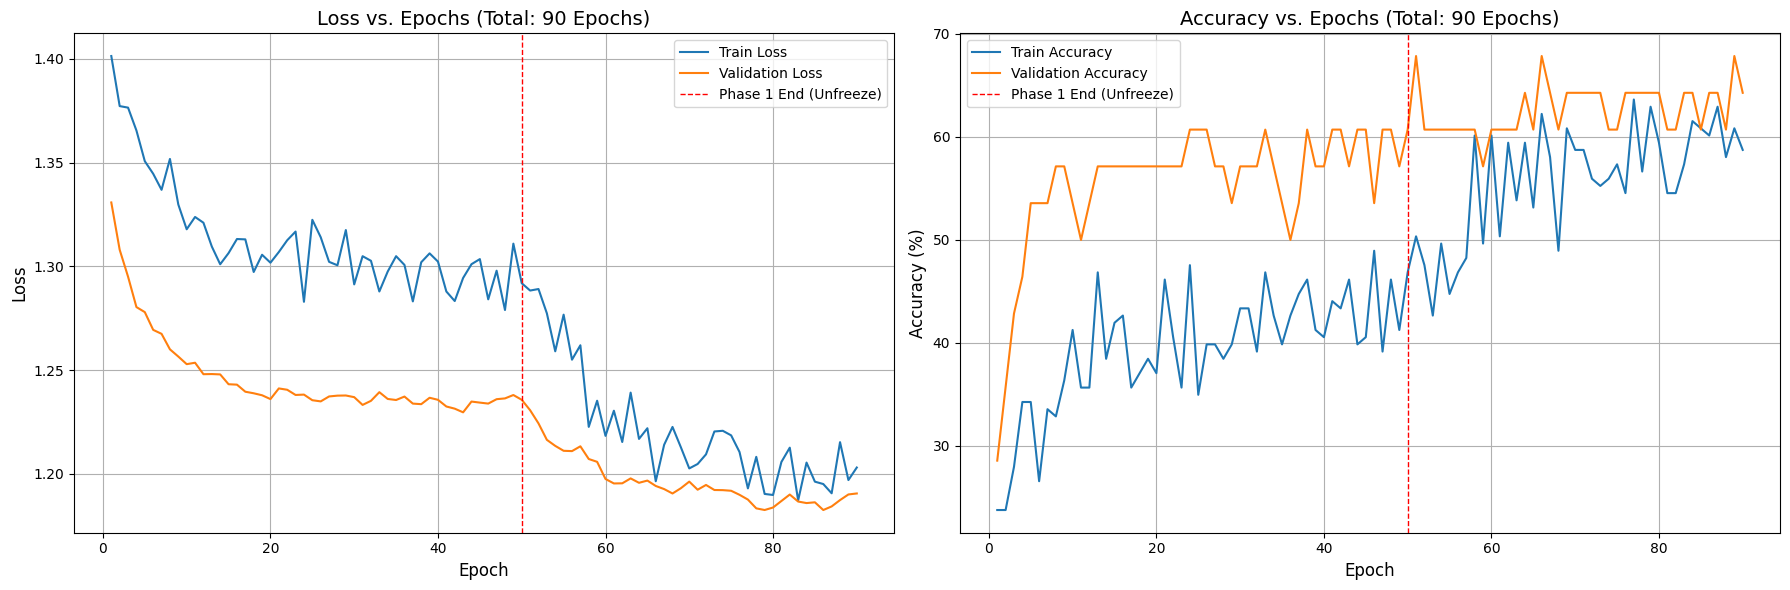

In [47]:
# PLOTTING TRAINING HISTORY (PHASE 1 + PHASE 2)

# The metric lists from Phase 1 (50 epochs) and Phase 2 (40 epochs) are concatenated
# to show the full 90-epoch training curve.

full_train_losses = train_losses + train_losses_ft
full_val_losses = val_losses + val_losses_ft
full_train_accs = train_accs + train_accs_ft
full_val_accs = val_accs + val_accs_ft

total_epochs = len(full_train_losses)
epochs_range = range(1, total_epochs + 1)

# Plot Loss and Accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# --- Plot Loss ---
ax1.plot(epochs_range, full_train_losses, label='Train Loss')
ax1.plot(epochs_range, full_val_losses, label='Validation Loss')

# Mark the transition between the two phases
ax1.axvline(x=len(train_losses), color='r', linestyle='--', linewidth=1, label='Phase 1 End (Unfreeze)')

ax1.set_title(f'Loss vs. Epochs (Total: {total_epochs} Epochs)', fontsize=14)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend()
ax1.grid(True)

# --- Plot Accuracy ---
ax2.plot(epochs_range, full_train_accs, label='Train Accuracy')
ax2.plot(epochs_range, full_val_accs, label='Validation Accuracy')

# Mark the transition between the two phases
ax2.axvline(x=len(train_losses), color='r', linestyle='--', linewidth=1, label='Phase 1 End (Unfreeze)')

ax2.set_title(f'Accuracy vs. Epochs (Total: {total_epochs} Epochs)', fontsize=14)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show() # Display the plot

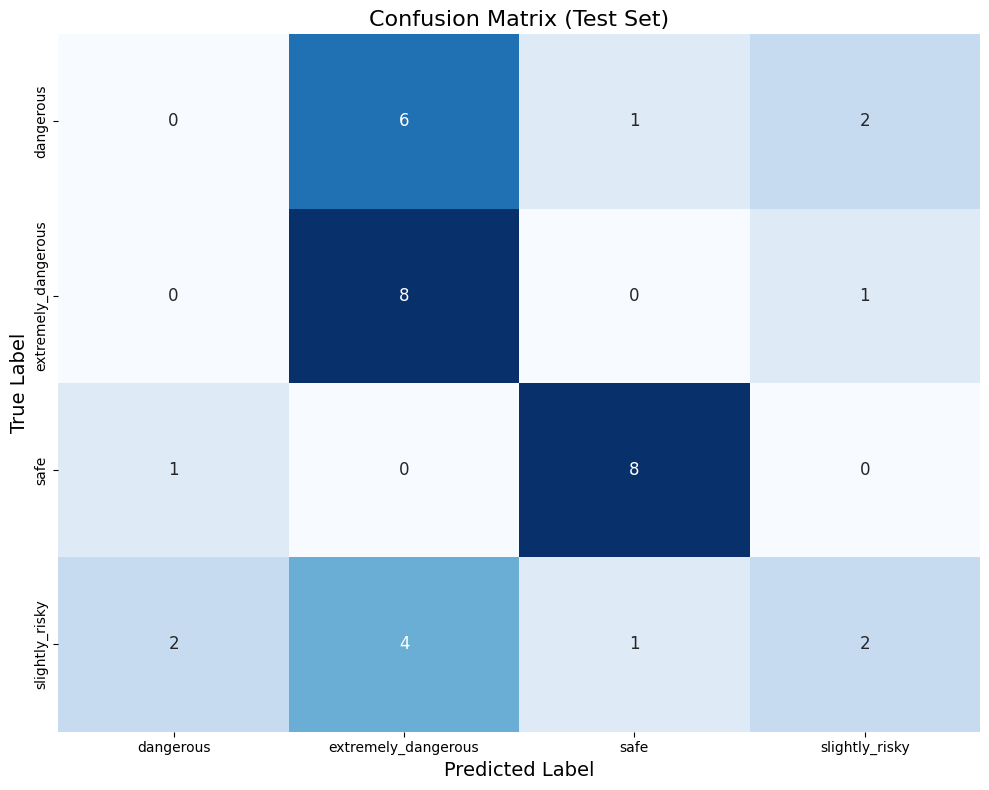


CONFIRMATION: Final fine-tuned model weights are saved at: /content/drive/MyDrive/EfficientNet_Final_Weights/efficientnet_b0_fine_tuned.pth


In [48]:
# PLOT CONFUSION MATRIX

from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd

# Generate Confusion Matrix data
cm = confusion_matrix(all_labels, all_preds)

# Create a DataFrame for better visualization with class labels
# class_names should be defined earlier (e.g., ['DANGEROUS', 'SAFE', ...])
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='g', cmap='Blues', cbar=False, annot_kws={"size": 12})
plt.title('Confusion Matrix (Test Set)', fontsize=16)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.tight_layout()
plt.show() # Display the plot

# SAVE FINAL WEIGHTS TO GDRIVE

# FINAL_SAVE_PATH = '/content/drive/MyDrive/EfficientNet_Final_Weights/efficientnet_b0_fine_tuned.pth'

# This confirms the final model state is saved to the correct location
torch.save(model_fine_tuned.state_dict(), FINAL_SAVE_PATH)

print(f"\nCONFIRMATION: Final fine-tuned model weights are saved at: {FINAL_SAVE_PATH}")